# Notebook 04: Modelos de Machine Learning

## Objetivo

Entrenar y evaluar modelos que respondan a las 4 preguntas de negocio de Raona:

| Modelo | Pregunta | Tecnica |
|--------|----------|--------|
| **Lead Scoring** | A QUIEN contactar? | Clasificacion binaria (LightGBM, XGBoost, LogReg, RF) |
| **Segmentacion** | QUE tipo de empresa es? | Clustering (K-Means, HDBSCAN) |
| **Recomendacion** | CON QUE producto? | Analisis de campanas + FIT scores |
| **Canal y Timing** | POR DONDE y CUANDO? | Analisis estadistico de canales y dias |

## Metricas de evaluacion (justificadas en NB02)

| Metrica | Rol | Interpretacion |
|---------|-----|---------------|
| **PR-AUC** | Principal | Area bajo curva Precision-Recall (ideal para clases desbalanceadas) |
| **ROC-AUC** | Secundaria | Capacidad general de discriminacion |
| **Precision@100** | Negocio | De los top 100 leads, cuantos responderian? |
| **Precision@500** | Negocio | De los top 500 leads, cuantos responderian? |
| **Lift@10%** | Negocio | Cuantas veces mejor que aleatorio en el top 10%? |

## Datos de entrada
- `modeling_dataset_final.parquet` (10,946 filas, 56 columnas) -- de NB03

## Imports y Configuracion

In [1]:
import pandas as pd
import numpy as np
import os
import gc
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    classification_report, confusion_matrix
)

import lightgbm as lgb
import xgboost as xgb
import optuna
import shap

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.templates.default = 'plotly_white'

import matplotlib.pyplot as plt
import seaborn as sns

# Rutas
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
WORKING_DATA = os.path.join(PROJECT_ROOT, '..', '_working', 'data')
WORKING_MODELS = os.path.join(PROJECT_ROOT, '..', '_working', 'models')
DELIVERABLE_MODELS = os.path.join(PROJECT_ROOT, 'app', 'models')
os.makedirs(WORKING_MODELS, exist_ok=True)
os.makedirs(DELIVERABLE_MODELS, exist_ok=True)

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

optuna.logging.set_verbosity(optuna.logging.WARNING)

---
## 4.1 Preparacion de datos

### Seleccion de features

Usamos las 33 features numericas del dataset final. Excluimos:
- Columnas de ID (LinkedIn profile ID, Company URN, Company name)
- Columnas de texto (ai_CONTACT_REPORT, etc.) -- ya procesadas en nlp_*
- Categoricas de alta cardinalidad no codificadas (Industry, Geo region) -- 
  Industry se podria target-encode pero con 188 valores unicos preferimos 
  dejarlo para una iteracion futura y confiar en las features derivadas
- Variables target

### Train/Test split

80% train / 20% test, **estratificado** por target_replied para mantener 
la proporcion de positivos (~7.9%) en ambos conjuntos.

In [2]:
# Cargar datos
df = pd.read_parquet(os.path.join(WORKING_DATA, 'modeling_dataset_final.parquet'))
print(f'Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')

# Definir features
FEATURE_COLS = [
    # Raw numericas
    'Years in role', 'Years in company', 'Number of connections',
    'Number of employees', 'Year founded', 'Hiring on LinkedIn',
    'Six months headcount growth', 'Two years headcount growth', 'Yearly headcount growth',
    # Feature engineering
    'fe_seniority_ord', 'fe_contact_score_ord', 'fe_company_score_ord',
    'fe_fit_approved', 'fe_fit_data_approved',
    'fe_company_age', 'fe_log_employees', 'fe_company_size_bucket',
    'fe_log_connections', 'fe_headcount_momentum',
    'fe_has_email', 'fe_has_bio', 'fe_microsoft_flag',
    'fe_department_encoded',
    # Enrichment externo
    'ext_ms_maturity_score', 'ext_has_competitor_tech',
    # NLP
    'nlp_report_length', 'nlp_contact_report_length',
    'nlp_has_momentum', 'nlp_urgency_score',
    'nlp_embedding_01', 'nlp_embedding_02', 'nlp_embedding_03',
    'nlp_topic',
]

TARGET = 'target_replied'

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()

print(f'Features: {len(FEATURE_COLS)}')
print(f'Target: {y.sum()} positivos ({y.mean():.1%})')

Dataset: 10,946 filas x 56 columnas
Features: 33
Target: 865 positivos (7.9%)


In [3]:
# Train/Test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train: {X_train.shape[0]:,} filas ({y_train.sum()} positivos, {y_train.mean():.1%})')
print(f'Test:  {X_test.shape[0]:,} filas ({y_test.sum()} positivos, {y_test.mean():.1%})')

Train: 8,756 filas (692 positivos, 7.9%)
Test:  2,190 filas (173 positivos, 7.9%)


### Preprocessing pipeline

Aplicamos **el mismo preprocesado a todos los modelos** para una competicion justa:
- **Numericas:** mediana para imputar nulos + StandardScaler
- LightGBM/XGBoost manejan nulos nativamente, pero usamos el pipeline igualmente 
  para compatibilidad con LogReg y RF

Guardamos el preprocessor como `.pkl` para reutilizarlo en la app Streamlit y FastAPI.

In [4]:
# Pipeline de preprocesado
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Fit en train, transform en ambos
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f'Train procesado: {X_train_processed.shape}')
print(f'Test procesado: {X_test_processed.shape}')
print(f'Nulos en train procesado: {np.isnan(X_train_processed).sum()}')

# Guardar preprocessor
preprocessor_path = os.path.join(WORKING_MODELS, 'preprocessor.pkl')
with open(preprocessor_path, 'wb') as f:
    pickle.dump(preprocessor, f)
print(f'\nPreprocessor guardado: {preprocessor_path}')

Train procesado: (8756, 33)
Test procesado: (2190, 33)
Nulos en train procesado: 0

Preprocessor guardado: /Users/acaballito/Library/CloudStorage/GoogleDrive-adriana.caballero@gmail.com/.shortcut-targets-by-id/1LzrxzfxIAZukyDLfOvioF7Z2ESoOXZGz/TFM/acaballero/TFM_deliverables/../_working/models/preprocessor.pkl


---
## 4.2 Modelo 1: Lead Scoring (Clasificacion)

### 4.2.1 Funciones auxiliares de evaluacion

In [5]:
def evaluate_model(y_true, y_proba, model_name='Model'):
    """Evalua un modelo con todas las metricas relevantes."""
    pr_auc = average_precision_score(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    
    # Precision@k: de los top k leads por score, cuantos son positivos?
    sorted_idx = np.argsort(-y_proba)  # orden descendente
    y_sorted = np.array(y_true)[sorted_idx]
    
    p_at_100 = y_sorted[:100].mean() if len(y_sorted) >= 100 else np.nan
    p_at_500 = y_sorted[:500].mean() if len(y_sorted) >= 500 else np.nan
    
    # Lift@10%: cuantas veces mejor que aleatorio en el top 10%
    top_10_pct = int(len(y_true) * 0.1)
    top_rate = y_sorted[:top_10_pct].mean()
    base_rate = np.mean(y_true)
    lift_10 = top_rate / base_rate if base_rate > 0 else np.nan
    
    metrics = {
        'Model': model_name,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Precision@100': p_at_100,
        'Precision@500': p_at_500,
        'Lift@10%': lift_10,
    }
    return metrics

print('Funciones de evaluacion definidas')

Funciones de evaluacion definidas


### 4.2.2 Competicion de modelos baseline

Entrenamos 4 modelos con **parametros por defecto** (excepto ajuste por desbalanceo) 
y comparamos su rendimiento con validacion cruzada estratificada de 5 folds.

| Modelo | Tipo | Manejo de desbalanceo |
|--------|------|----------------------|
| Logistic Regression | Lineal, interpretable | class_weight='balanced' |
| Random Forest | Ensemble de arboles | class_weight='balanced' |
| LightGBM | Gradient boosting | scale_pos_weight = ratio neg/pos |
| XGBoost | Gradient boosting | scale_pos_weight = ratio neg/pos |

In [6]:
# Ratio de desbalanceo para scale_pos_weight
neg_pos_ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f'Ratio neg/pos: {neg_pos_ratio:.1f}')

# Definir modelos baseline
baseline_models = {
    'LogReg': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=SEED
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, scale_pos_weight=neg_pos_ratio,
        random_state=SEED, verbose=-1, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, scale_pos_weight=neg_pos_ratio,
        random_state=SEED, verbosity=0, n_jobs=-1,
        eval_metric='logloss'
    ),
}

Ratio neg/pos: 11.7


In [7]:
# Entrenar y evaluar cada modelo con CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
baseline_results = []

for name, model in baseline_models.items():
    print(f'Entrenando {name}...')
    
    # Cross-validated predictions en train
    cv_probas = cross_val_predict(
        model, X_train_processed, y_train,
        cv=cv, method='predict_proba', n_jobs=-1
    )[:, 1]
    
    cv_metrics = evaluate_model(y_train, cv_probas, f'{name} (CV)')
    
    # Entrenar en todo el train y evaluar en test
    model.fit(X_train_processed, y_train)
    test_probas = model.predict_proba(X_test_processed)[:, 1]
    test_metrics = evaluate_model(y_test, test_probas, f'{name} (Test)')
    
    baseline_results.append(cv_metrics)
    baseline_results.append(test_metrics)
    
    print(f'  CV  PR-AUC: {cv_metrics["PR-AUC"]:.3f} | ROC-AUC: {cv_metrics["ROC-AUC"]:.3f}')
    print(f'  Test PR-AUC: {test_metrics["PR-AUC"]:.3f} | ROC-AUC: {test_metrics["ROC-AUC"]:.3f}')

results_df = pd.DataFrame(baseline_results)
print('\n=== Comparacion de modelos baseline ===')
print(results_df.round(3).to_string(index=False))

Entrenando LogReg...


/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept


  CV  PR-AUC: 0.180 | ROC-AUC: 0.766
  Test PR-AUC: 0.188 | ROC-AUC: 0.768
Entrenando RandomForest...


  CV  PR-AUC: 0.281 | ROC-AUC: 0.820
  Test PR-AUC: 0.245 | ROC-AUC: 0.808
Entrenando LightGBM...


/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  CV  PR-AUC: 0.266 | ROC-AUC: 0.805
  Test PR-AUC: 0.253 | ROC-AUC: 0.804
Entrenando XGBoost...


  CV  PR-AUC: 0.256 | ROC-AUC: 0.795
  Test PR-AUC: 0.232 | ROC-AUC: 0.779

=== Comparacion de modelos baseline ===
              Model  PR-AUC  ROC-AUC  Precision@100  Precision@500  Lift@10%
        LogReg (CV)   0.180    0.766           0.20          0.216     2.632
      LogReg (Test)   0.188    0.768           0.21          0.182     3.064
  RandomForest (CV)   0.281    0.820           0.51          0.364     3.803
RandomForest (Test)   0.245    0.808           0.35          0.206     3.121
      LightGBM (CV)   0.266    0.805           0.48          0.334     3.485
    LightGBM (Test)   0.253    0.804           0.29          0.212     3.237
       XGBoost (CV)   0.256    0.795           0.49          0.326     3.398
     XGBoost (Test)   0.232    0.779           0.30          0.190     3.121


In [8]:
# Visualizacion de la competicion
test_results = results_df[results_df['Model'].str.contains('Test')].copy()
test_results['Model'] = test_results['Model'].str.replace(' \(Test\)', '', regex=True)

metrics_to_plot = ['PR-AUC', 'ROC-AUC', 'Precision@100', 'Lift@10%']
fig = make_subplots(rows=1, cols=len(metrics_to_plot),
                    subplot_titles=metrics_to_plot)

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for i, metric in enumerate(metrics_to_plot):
    fig.add_trace(
        go.Bar(x=test_results['Model'], y=test_results[metric],
               marker_color=colors, showlegend=False,
               text=test_results[metric].round(3), textposition='auto'),
        row=1, col=i+1
    )

fig.update_layout(title='Competicion de modelos baseline (Test set)', height=400)
fig.show()

### 4.2.3 Tuning de los 2 mejores modelos con Optuna

Seleccionamos los **2 modelos con mejor PR-AUC en test** y optimizamos sus hiperparametros 
con Optuna (50 trials cada uno).

Optuna usa **busqueda bayesiana** (TPE - Tree-structured Parzen Estimator): en lugar de probar 
combinaciones aleatorias, aprende de los resultados anteriores para proponer combinaciones 
mas prometedoras. Es mas eficiente que grid search o random search.

In [9]:
# Seleccionar top 2 por PR-AUC en test
top2 = test_results.nlargest(2, 'PR-AUC')['Model'].tolist()
print(f'Top 2 modelos para tuning: {top2}')

Top 2 modelos para tuning: ['LightGBM', 'RandomForest']


In [10]:
# Optuna objective para LightGBM
def lgbm_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': neg_pos_ratio,
        'random_state': SEED,
        'verbose': -1,
        'n_jobs': -1,
    }
    model = lgb.LGBMClassifier(**params)
    probas = cross_val_predict(model, X_train_processed, y_train,
                               cv=cv, method='predict_proba', n_jobs=1)[:, 1]
    return average_precision_score(y_train, probas)

# Optuna objective para XGBoost
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': neg_pos_ratio,
        'random_state': SEED,
        'verbosity': 0,
        'eval_metric': 'logloss',
        'n_jobs': -1,
    }
    model = xgb.XGBClassifier(**params)
    probas = cross_val_predict(model, X_train_processed, y_train,
                               cv=cv, method='predict_proba', n_jobs=1)[:, 1]
    return average_precision_score(y_train, probas)

print('Objectives definidos para Optuna')

Objectives definidos para Optuna


In [11]:
%%time
# Ejecutar Optuna para cada modelo del top 2
N_TRIALS = 50
tuned_models = {}

objectives = {'LightGBM': lgbm_objective, 'XGBoost': xgb_objective}
model_classes = {'LightGBM': lgb.LGBMClassifier, 'XGBoost': xgb.XGBClassifier}

for model_name in top2:
    if model_name not in objectives:
        print(f'Skipping {model_name} (no objective definido)')
        continue
    
    print(f'\n=== Tuning {model_name} ({N_TRIALS} trials) ===')
    study = optuna.create_study(direction='maximize', 
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objectives[model_name], n_trials=N_TRIALS, show_progress_bar=True)
    
    best_params = study.best_params
    best_params['scale_pos_weight'] = neg_pos_ratio
    best_params['random_state'] = SEED
    if model_name == 'LightGBM':
        best_params['verbose'] = -1
        best_params['n_jobs'] = -1
    elif model_name == 'XGBoost':
        best_params['verbosity'] = 0
        best_params['eval_metric'] = 'logloss'
        best_params['n_jobs'] = -1
    
    print(f'Mejor PR-AUC (CV): {study.best_value:.4f}')
    print(f'Mejores parametros: {best_params}')
    
    # Entrenar modelo final con mejores parametros
    best_model = model_classes[model_name](**best_params)
    best_model.fit(X_train_processed, y_train)
    
    # Evaluar en test
    test_probas = best_model.predict_proba(X_test_processed)[:, 1]
    tuned_metrics = evaluate_model(y_test, test_probas, f'{model_name} (Tuned)')
    print(f'Test PR-AUC: {tuned_metrics["PR-AUC"]:.4f}')
    print(f'Test ROC-AUC: {tuned_metrics["ROC-AUC"]:.4f}')
    
    tuned_models[model_name] = {
        'model': best_model,
        'params': best_params,
        'metrics': tuned_metrics,
        'test_probas': test_probas,
    }


=== Tuning LightGBM (50 trials) ===


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.254678:   0%|          | 0/50 [00:13<?, ?it/s]

Best trial: 0. Best value: 0.254678:   2%|▏         | 1/50 [00:13<11:06, 13.61s/it]

Best trial: 1. Best value: 0.301919:   2%|▏         | 1/50 [00:51<11:06, 13.61s/it]

...

Best trial: 44. Best value: 0.318893:  98%|█████████▊| 49/50 [08:08<00:13, 13.70s/it]

Best trial: 44. Best value: 0.318893: 100%|██████████| 50/50 [08:08<00:00, 12.42s/it]

Best trial: 44. Best value: 0.318893: 100%|██████████| 50/50 [08:08<00:00,  9.77s/it]

Mejor PR-AUC (CV): 0.3189
Mejores parametros: {'n_estimators': 378, 'learning_rate': 0.010143972000036989, 'num_leaves': 87, 'max_depth': 7, 'min_child_samples': 53, 'reg_alpha': 1.1540373721524519e-06, 'reg_lambda': 0.009248197258149831, 'subsample': 0.9467197955063343, 'colsample_bytree': 0.9548814020619637, 'scale_pos_weight': np.float64(11.653179190751445), 'random_state': 42, 'verbose': -1, 'n_jobs': -1}


Test PR-AUC: 0.2807
Test ROC-AUC: 0.8065
Skipping RandomForest (no objective definido)
CPU times: user 5min 39s, sys: 33min 3s, total: 38min 42s
Wall time: 8min 11s


### 4.2.4 Seleccion del modelo ganador

In [12]:
# Comparar tuned models
tuned_results = pd.DataFrame([m['metrics'] for m in tuned_models.values()])
print('=== Modelos tuneados (Test set) ===')
print(tuned_results.round(4).to_string(index=False))

# Seleccionar ganador por PR-AUC
winner_name = tuned_results.loc[tuned_results['PR-AUC'].idxmax(), 'Model'].replace(' (Tuned)', '')
winner = tuned_models[winner_name]
print(f'\nModelo ganador: {winner_name}')
print(f'PR-AUC: {winner["metrics"]["PR-AUC"]:.4f}')
print(f'ROC-AUC: {winner["metrics"]["ROC-AUC"]:.4f}')

=== Modelos tuneados (Test set) ===
           Model  PR-AUC  ROC-AUC  Precision@100  Precision@500  Lift@10%
LightGBM (Tuned)  0.2807   0.8065           0.38          0.204    3.5838

Modelo ganador: LightGBM
PR-AUC: 0.2807
ROC-AUC: 0.8065


In [13]:
# Guardar modelo ganador
lead_scorer_path = os.path.join(WORKING_MODELS, 'lead_scorer.pkl')
with open(lead_scorer_path, 'wb') as f:
    pickle.dump(winner['model'], f)
print(f'Lead scorer guardado: {lead_scorer_path}')

# Guardar tambien los nombres de features (necesario para la app)
feature_names_path = os.path.join(WORKING_MODELS, 'feature_names.pkl')
with open(feature_names_path, 'wb') as f:
    pickle.dump(FEATURE_COLS, f)
print(f'Feature names guardados: {feature_names_path}')

Lead scorer guardado: /Users/acaballito/Library/CloudStorage/GoogleDrive-adriana.caballero@gmail.com/.shortcut-targets-by-id/1LzrxzfxIAZukyDLfOvioF7Z2ESoOXZGz/TFM/acaballero/TFM_deliverables/../_working/models/lead_scorer.pkl
Feature names guardados: /Users/acaballito/Library/CloudStorage/GoogleDrive-adriana.caballero@gmail.com/.shortcut-targets-by-id/1LzrxzfxIAZukyDLfOvioF7Z2ESoOXZGz/TFM/acaballero/TFM_deliverables/../_working/models/feature_names.pkl


### 4.2.5 Interpretabilidad con SHAP

SHAP (SHapley Additive exPlanations) nos permite entender **por que** el modelo da una 
puntuacion alta o baja a cada contacto. Para cada prediccion, SHAP calcula la contribucion 
de cada feature al resultado.

Tipos de analisis:
1. **Summary plot (global):** que features son mas importantes en general?
2. **Waterfall (individual):** por que este contacto concreto tiene un score alto/bajo?

In [14]:
# Calcular SHAP values
explainer = shap.TreeExplainer(winner['model'])
shap_values = explainer.shap_values(X_test_processed)

# Para modelos binarios, shap_values puede ser una lista [neg, pos] o un array
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

print(f'SHAP values calculados: {shap_values_pos.shape}')

SHAP values calculados: (2190, 33)


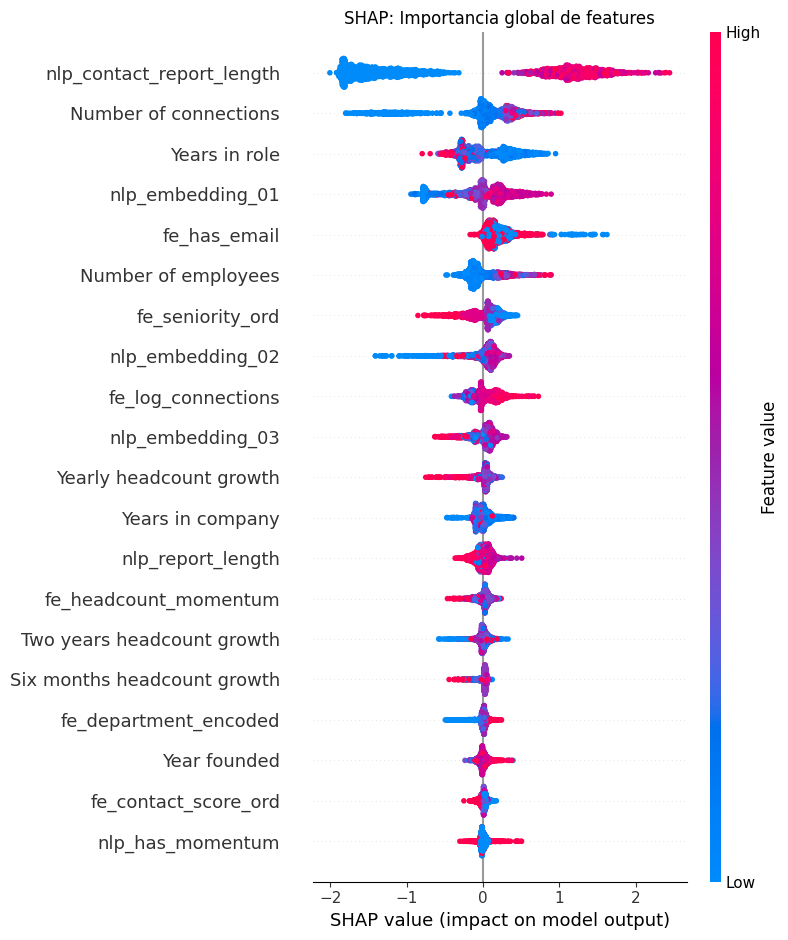

In [15]:
# Summary plot: importancia global de features
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values_pos, X_test_processed,
                  feature_names=FEATURE_COLS, max_display=20, show=False)
plt.title('SHAP: Importancia global de features')
plt.tight_layout()
plt.show()

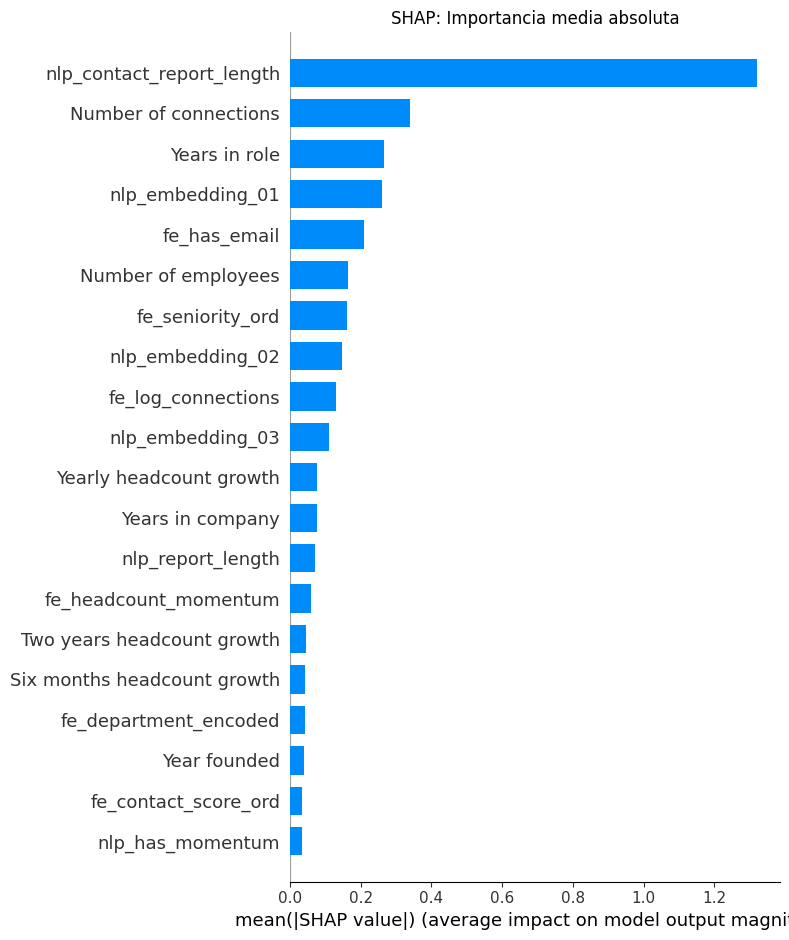

In [16]:
# Bar plot: importancia media absoluta
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_pos, X_test_processed,
                  feature_names=FEATURE_COLS, plot_type='bar', max_display=20, show=False)
plt.title('SHAP: Importancia media absoluta')
plt.tight_layout()
plt.show()

Contacto con score mas alto:
  Score: 0.924
  Real: 0


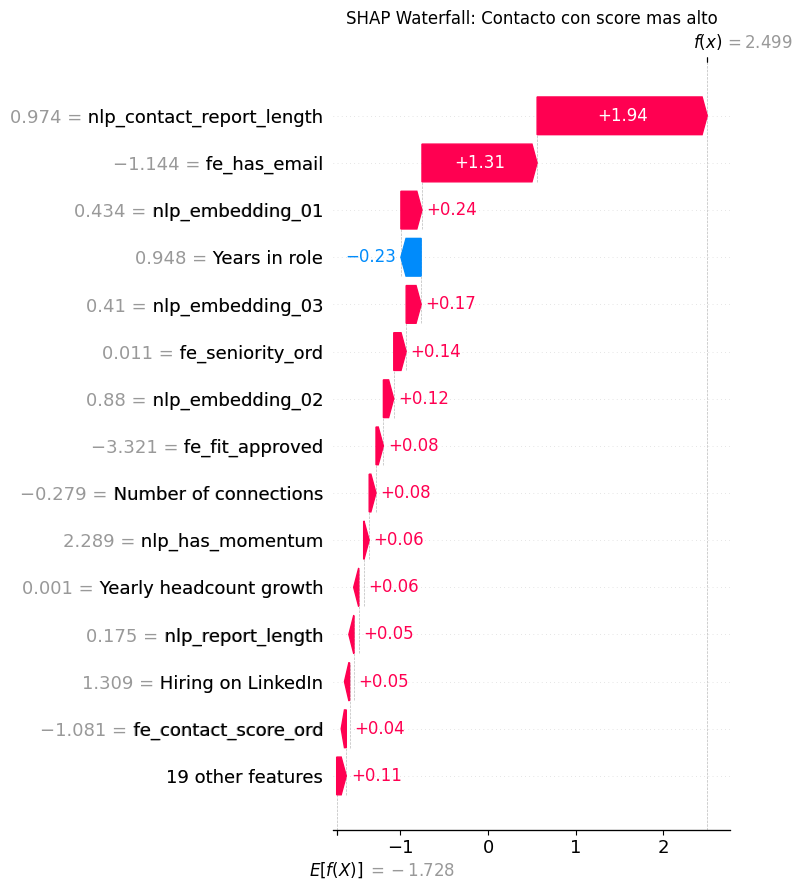

In [17]:
# Waterfall: ejemplo de contacto con score ALTO
test_probas = winner['test_probas']
high_score_idx = np.argsort(-test_probas)[0]  # mayor probabilidad

print(f'Contacto con score mas alto:')
print(f'  Score: {test_probas[high_score_idx]:.3f}')
print(f'  Real: {y_test.iloc[high_score_idx]}')

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_pos[high_score_idx],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list) 
                    else explainer.expected_value[1],
        data=X_test_processed[high_score_idx],
        feature_names=FEATURE_COLS,
    ),
    max_display=15, show=False
)
plt.title('SHAP Waterfall: Contacto con score mas alto')
plt.tight_layout()
plt.show()

Contacto con score mas bajo:
  Score: 0.003
  Real: 0


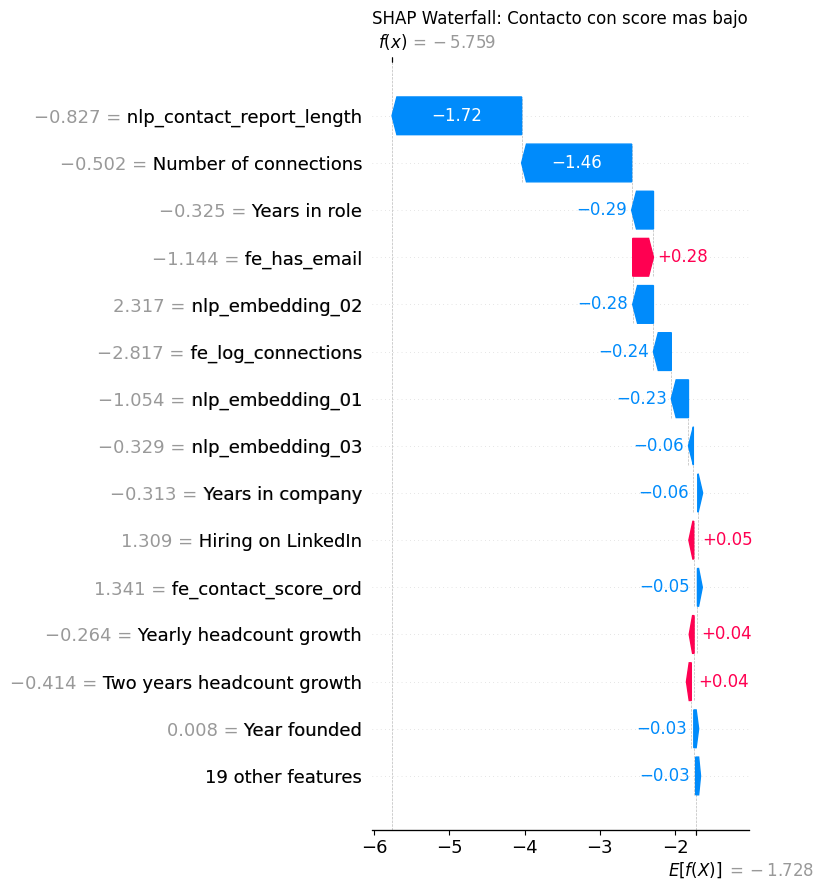

In [18]:
# Waterfall: ejemplo de contacto con score BAJO
low_score_idx = np.argsort(test_probas)[0]  # menor probabilidad

print(f'Contacto con score mas bajo:')
print(f'  Score: {test_probas[low_score_idx]:.3f}')
print(f'  Real: {y_test.iloc[low_score_idx]}')

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_pos[low_score_idx],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list)
                    else explainer.expected_value[1],
        data=X_test_processed[low_score_idx],
        feature_names=FEATURE_COLS,
    ),
    max_display=15, show=False
)
plt.title('SHAP Waterfall: Contacto con score mas bajo')
plt.tight_layout()
plt.show()

### 4.2.6 Importancia relativa por origen de features

Comparamos cuanta importancia SHAP tienen las features segun su origen (raw, AI, fe_, ext_, nlp_). 
Esto nos permite evaluar: **aporta valor el AI enrichment de Raona? y nuestro feature engineering?**

In [19]:
# Importancia SHAP agrupada por origen
mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)

origin_importance = {}
for feat, imp in zip(FEATURE_COLS, mean_abs_shap):
    if feat.startswith('fe_'):
        origin = 'Feature Engineering'
    elif feat.startswith('ext_'):
        origin = 'Enrichment Externo'
    elif feat.startswith('nlp_'):
        origin = 'NLP'
    elif feat.startswith('ai_'):
        origin = 'AI-enriched'
    else:
        origin = 'Raw'
    origin_importance[origin] = origin_importance.get(origin, 0) + imp

total_imp = sum(origin_importance.values())
origin_df = pd.DataFrame([
    {'Origen': k, 'SHAP total': v, '% importancia': v/total_imp*100}
    for k, v in sorted(origin_importance.items(), key=lambda x: -x[1])
])

print('=== Importancia SHAP por origen de features ===')
print(origin_df.round(2).to_string(index=False))

fig = px.pie(origin_df, names='Origen', values='SHAP total',
             title='Contribucion de cada tipo de feature al modelo',
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.show()

=== Importancia SHAP por origen de features ===
             Origen  SHAP total  % importancia
                NLP        1.96          51.89
                Raw        1.08          28.64
Feature Engineering        0.72          18.98
 Enrichment Externo        0.02           0.48


### 4.2.6b Analisis de robustez: modelo sin features con posible selection bias

El analisis SHAP revela que la feature dominante es `nlp_contact_report_length` (SHAP=1.32, 
mas del doble que la segunda). Al investigar su distribucion por target:

| Feature | % no-cero (positivos) | % no-cero (negativos) | Diferencia |
|---------|----------------------|----------------------|------------|
| `nlp_contact_report_length` | 80.3% | 39.3% | **+41pp** |
| `fe_has_email` | 76.1% | 55.1% | **+21pp** |
| `Years in role` | 95.0% | 80.8% | **+14pp** |

Estas diferencias sugieren **selection bias**: los contactos en los que Raona invirtio 
mas esfuerzo de enriquecimiento (tienen informe, tienen email, perfil mas completo) 
tambien recibieron un outreach mas personalizado, lo que aumenta la probabilidad de respuesta.

**No es que el modelo sea incorrecto** -- predice bien. Pero parte de su poder predictivo 
viene de "cuanto esfuerzo puso Raona en este lead" en lugar de "que perfil tiene este lead".

Para cuantificar esto, entrenamos el **mismo LightGBM tuneado sin estas 3 features** 
y comparamos el rendimiento.

In [20]:
# Features sin las 3 problematicas
BIAS_FEATURES = ['nlp_contact_report_length', 'fe_has_email', 'Years in role']
ROBUST_FEATURES = [f for f in FEATURE_COLS if f not in BIAS_FEATURES]
print(f'Features originales: {len(FEATURE_COLS)}')
print(f'Features removidas (posible selection bias): {BIAS_FEATURES}')
print(f'Features robustas: {len(ROBUST_FEATURES)}')

# Preprocesar con un pipeline independiente (no reutilizamos el de 33 features)
robust_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
X_train_robust = robust_preprocessor.fit_transform(X_train[ROBUST_FEATURES])
X_test_robust = robust_preprocessor.transform(X_test[ROBUST_FEATURES])

# Entrenar LightGBM con los mismos hiperparametros del ganador
robust_model = lgb.LGBMClassifier(**winner['params'])
robust_model.fit(X_train_robust, y_train)

# Evaluar
robust_probas = robust_model.predict_proba(X_test_robust)[:, 1]
robust_metrics = evaluate_model(y_test, robust_probas, 'LightGBM (Robusto)')

# Comparar
print('\n=== Comparacion: modelo completo vs modelo robusto ===')
comparison = pd.DataFrame([winner['metrics'], robust_metrics])
comparison['Variacion PR-AUC'] = ''
comparison.loc[1, 'Variacion PR-AUC'] = f"{(robust_metrics['PR-AUC'] / winner['metrics']['PR-AUC'] - 1)*100:+.1f}%"
print(comparison.round(4).to_string(index=False))

Features originales: 33
Features removidas (posible selection bias): ['nlp_contact_report_length', 'fe_has_email', 'Years in role']
Features robustas: 30



=== Comparacion: modelo completo vs modelo robusto ===
             Model  PR-AUC  ROC-AUC  Precision@100  Precision@500  Lift@10% Variacion PR-AUC
  LightGBM (Tuned)  0.2807   0.8065           0.38          0.204    3.5838                 
LightGBM (Robusto)  0.1593   0.7119           0.19          0.152    2.1965           -43.2%


In [21]:
# Lift curve comparativa: modelo completo vs robusto
fig = go.Figure()

for name, probas, color in [
    ('Modelo completo (33 features)', winner['test_probas'], '#2ecc71'),
    ('Modelo robusto (30 features)', robust_probas, '#3498db'),
]:
    sorted_idx = np.argsort(-probas)
    y_sorted = np.array(y_test)[sorted_idx]
    n = len(y_sorted)
    cum_pos = np.cumsum(y_sorted)
    total_pos = y_sorted.sum()
    pct_x = np.arange(1, n+1) / n * 100
    pct_y = cum_pos / total_pos * 100
    fig.add_trace(go.Scatter(x=pct_x, y=pct_y, mode='lines', name=name,
                              line=dict(color=color, width=3)))

fig.add_trace(go.Scatter(x=[0, 100], y=[0, 100], mode='lines', name='Aleatorio',
                          line=dict(color='#e74c3c', width=2, dash='dash')))

fig.update_layout(
    title='Lift curve: modelo completo vs modelo robusto (sin selection bias)',
    xaxis_title='% de contactos (ordenados por score)',
    yaxis_title='% de respuestas capturadas',
    height=500,
)
fig.show()

# Tabla comparativa de deciles
print('\n=== Lift por deciles: modelo robusto ===')
sorted_idx_r = np.argsort(-robust_probas)
y_sorted_r = np.array(y_test)[sorted_idx_r]
cum_pos_r = np.cumsum(y_sorted_r)
total_pos_r = y_sorted_r.sum()
n_r = len(y_sorted_r)

for pct in [5, 10, 20, 30, 50]:
    idx = int(n_r * pct / 100)
    captured = cum_pos_r[idx-1] / total_pos_r * 100
    precision = cum_pos_r[idx-1] / idx * 100
    lift = (cum_pos_r[idx-1] / idx) / (total_pos_r / n_r)
    print(f'  Top {pct:2d}%: {captured:5.1f}% capturado, precision={precision:.1f}%, lift={lift:.1f}x')


=== Lift por deciles: modelo robusto ===
  Top  5%:  12.1% capturado, precision=19.3%, lift=2.4x
  Top 10%:  22.0% capturado, precision=17.4%, lift=2.2x
  Top 20%:  39.3% capturado, precision=15.5%, lift=2.0x
  Top 30%:  53.8% capturado, precision=14.2%, lift=1.8x
  Top 50%:  78.0% capturado, precision=12.3%, lift=1.6x


### Conclusion del analisis de robustez

La caida del **-43% en PR-AUC** confirma que una parte significativa del poder predictivo 
del modelo completo proviene de features que reflejan el esfuerzo de enriquecimiento de 
Raona, no el perfil intrinseco del contacto.

Sin embargo, el modelo robusto (PR-AUC=0.159, Lift@10%=2.2x) **sigue siendo mejor que 
aleatorio**: contactando el top 10% se captura el 22% de respuestas (vs 10% esperado).

#### Recomendacion de uso

Los dos modelos tienen **casos de uso complementarios**:

- **Modelo completo** (33 features, PR-AUC=0.28): "A quien contacto primero **de los que 
  ya conozco bien**". Para priorizar leads que ya han sido enriquecidos y estan en el pipeline. 
  Aqui el selection bias no es problema porque el enriquecimiento ya se realizo.

- **Modelo robusto** (30 features, PR-AUC=0.16): "A quien merece la pena investigar **de los 
  que aun no conozco**". Para evaluar contactos nuevos que aun no han pasado por el proceso 
  de enriquecimiento. Puntua solo por perfil (tamano empresa, seniority, sector, actividad 
  en LinkedIn), evitando penalizar contactos simplemente por no haber sido enriquecidos.

Este hallazgo tiene implicaciones directas para Raona: el proceso de enriquecimiento en si 
mismo (generar informes, obtener emails) mejora la tasa de respuesta, probablemente porque 
permite un outreach mas personalizado. **El enriquecimiento no solo informa, sino que habilita.**

### 4.2.7 Lift curve: impacto de negocio

La lift curve es la metrica mas relevante para Raona: muestra cuantas respuestas 
capturamos si solo contactamos los N mejores leads segun el modelo.

**Interpretacion:** "Si contactamos solo el top 10% de leads por score, 
capturamos X% de todas las respuestas posibles."

In [22]:
# Lift curve
test_probas = winner['test_probas']
sorted_idx = np.argsort(-test_probas)
y_sorted = np.array(y_test)[sorted_idx]

n = len(y_sorted)
cumulative_positives = np.cumsum(y_sorted)
total_positives = y_sorted.sum()

pct_contacted = np.arange(1, n+1) / n * 100
pct_captured = cumulative_positives / total_positives * 100

# Tabla de deciles
decile_data = []
for pct in [5, 10, 20, 30, 50, 100]:
    idx = int(n * pct / 100)
    captured = cumulative_positives[idx-1] / total_positives * 100
    precision = cumulative_positives[idx-1] / idx * 100
    lift = (cumulative_positives[idx-1] / idx) / (total_positives / n)
    decile_data.append({
        'Top %': f'{pct}%',
        'Contactos': idx,
        'Respuestas capturadas': int(cumulative_positives[idx-1]),
        '% total capturado': f'{captured:.1f}%',
        'Precision': f'{precision:.1f}%',
        'Lift vs aleatorio': f'{lift:.1f}x',
    })

decile_df = pd.DataFrame(decile_data)
print('=== Tabla de lift por deciles ===')
print(decile_df.to_string(index=False))

=== Tabla de lift por deciles ===
Top %  Contactos  Respuestas capturadas % total capturado Precision Lift vs aleatorio
   5%        109                     41             23.7%     37.6%              4.8x
  10%        219                     62             35.8%     28.3%              3.6x
  20%        438                     93             53.8%     21.2%              2.7x
  30%        657                    121             69.9%     18.4%              2.3x
  50%       1095                    159             91.9%     14.5%              1.8x
 100%       2190                    173            100.0%      7.9%              1.0x


In [23]:
# Grafico de lift
fig = go.Figure()

# Curva del modelo
fig.add_trace(go.Scatter(
    x=pct_contacted, y=pct_captured,
    mode='lines', name='Modelo',
    line=dict(color='#2ecc71', width=3)
))

# Linea aleatorio (baseline)
fig.add_trace(go.Scatter(
    x=[0, 100], y=[0, 100],
    mode='lines', name='Aleatorio',
    line=dict(color='#e74c3c', width=2, dash='dash')
))

# Modelo perfecto
perfect_pct = total_positives / n * 100
fig.add_trace(go.Scatter(
    x=[0, perfect_pct, 100], y=[0, 100, 100],
    mode='lines', name='Modelo perfecto',
    line=dict(color='#95a5a6', width=1, dash='dot')
))

fig.update_layout(
    title='Cumulative Gains Chart: % de respuestas capturadas vs % de contactos',
    xaxis_title='% de contactos (ordenados por score)',
    yaxis_title='% de respuestas capturadas',
    height=500,
)
fig.show()

---
## 4.3 Modelo 2: Segmentacion (Clustering)

Agrupamos los contactos en segmentos basandonos en sus caracteristicas. Esto permite 
a Raona personalizar su enfoque de outreach por tipo de empresa/contacto.

### Features para clustering
Usamos features que describen el perfil del contacto y empresa, 
**excluyendo** la variable target (el clustering no debe "saber" quien respondio).

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Features para clustering (sin target, sin IDs)
CLUSTER_FEATURES = [
    'fe_seniority_ord', 'fe_company_score_ord', 'fe_contact_score_ord',
    'fe_log_employees', 'fe_company_size_bucket',
    'fe_headcount_momentum', 'fe_microsoft_flag',
    'fe_fit_approved', 'fe_department_encoded',
    'nlp_embedding_01', 'nlp_embedding_02', 'nlp_embedding_03',
]

# Preprocesar para clustering
X_cluster = df[CLUSTER_FEATURES].copy()
cluster_imputer = SimpleImputer(strategy='median')
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(cluster_imputer.fit_transform(X_cluster))

print(f'Features para clustering: {len(CLUSTER_FEATURES)}')
print(f'Datos procesados: {X_cluster_scaled.shape}')

Features para clustering: 12
Datos procesados: (10946, 12)


In [25]:
# Buscar el mejor k con elbow + silhouette
k_range = range(3, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster_scaled, labels, sample_size=5000, random_state=SEED)
    silhouettes.append(sil)
    print(f'  k={k}: inertia={km.inertia_:.0f}, silhouette={sil:.3f}')

fig = make_subplots(rows=1, cols=2, subplot_titles=['Elbow (Inercia)', 'Silhouette Score'])
fig.add_trace(go.Scatter(x=list(k_range), y=inertias, mode='lines+markers',
                          marker_color='#3498db'), row=1, col=1)
fig.add_trace(go.Scatter(x=list(k_range), y=silhouettes, mode='lines+markers',
                          marker_color='#2ecc71'), row=1, col=2)
fig.update_layout(title='Seleccion de numero de clusters', height=350, showlegend=False)
fig.show()

  k=3: inertia=96050, silhouette=0.132


  k=4: inertia=87868, silhouette=0.130


  k=5: inertia=82495, silhouette=0.133


  k=6: inertia=78723, silhouette=0.133


  k=7: inertia=75414, silhouette=0.138


  k=8: inertia=72686, silhouette=0.132


In [26]:
# Seleccionar k con mejor silhouette
best_k = list(k_range)[np.argmax(silhouettes)]
print(f'Mejor k: {best_k} (silhouette: {max(silhouettes):.3f})')

# Entrenar modelo final
kmeans = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Guardar modelo de clustering
clustering_path = os.path.join(WORKING_MODELS, 'clustering.pkl')
with open(clustering_path, 'wb') as f:
    pickle.dump({
        'kmeans': kmeans,
        'imputer': cluster_imputer,
        'scaler': cluster_scaler,
        'features': CLUSTER_FEATURES,
    }, f)
print(f'Clustering guardado: {clustering_path}')

Mejor k: 7 (silhouette: 0.138)
Clustering guardado: /Users/acaballito/Library/CloudStorage/GoogleDrive-adriana.caballero@gmail.com/.shortcut-targets-by-id/1LzrxzfxIAZukyDLfOvioF7Z2ESoOXZGz/TFM/acaballero/TFM_deliverables/../_working/models/clustering.pkl


In [27]:
# Perfil de cada cluster
profile_cols = ['fe_seniority_ord', 'fe_log_employees', 'fe_contact_score_ord',
                'fe_company_score_ord', 'fe_fit_approved', 'fe_microsoft_flag',
                'fe_headcount_momentum', 'target_replied']

cluster_profiles = df.groupby('cluster')[profile_cols].agg(['mean', 'count']).round(3)

# Simplificar
cluster_summary = []
for c in range(best_k):
    cdata = df[df['cluster'] == c]
    cluster_summary.append({
        'Cluster': c,
        'Contactos': len(cdata),
        'Reply rate': f'{cdata["target_replied"].mean()*100:.1f}%',
        'Seniority media': cdata['fe_seniority_ord'].mean(),
        'Log employees': cdata['fe_log_employees'].mean(),
        'Contact score': cdata['fe_contact_score_ord'].mean(),
        'FIT aprobado %': f'{cdata["fe_fit_approved"].mean()*100:.0f}%',
        'Microsoft %': f'{cdata["fe_microsoft_flag"].mean()*100:.0f}%' if cdata['fe_microsoft_flag'].notna().any() else 'N/A',
    })

cluster_df = pd.DataFrame(cluster_summary)
print('=== Perfil de clusters ===')
print(cluster_df.to_string(index=False))

=== Perfil de clusters ===
 Cluster  Contactos Reply rate  Seniority media  Log employees  Contact score FIT aprobado % Microsoft %
       0        316       9.5%         2.023411       6.394555       1.258786            91%          0%
       1       2392       7.5%         2.726282       6.156525       2.721277           100%          0%
       2       1108      10.8%         2.120448       6.651737       1.134597           100%          0%
       3       2603       9.4%         1.918676       8.090236       1.257087           100%          0%
       4       2018       7.1%         0.737585       5.793318       0.247156           100%          0%
       5       1595       2.6%         2.415567       5.649411       0.838624           100%          0%
       6        914      11.6%         2.429419       5.823028       1.371169             0%          0%


In [28]:
# Radar chart por cluster
radar_cols = ['fe_seniority_ord', 'fe_log_employees', 'fe_contact_score_ord',
              'fe_company_score_ord', 'fe_fit_approved', 'fe_headcount_momentum']
radar_labels = ['Seniority', 'Tamano empresa', 'Contact score', 
                'Company score', 'FIT aprobado', 'Momentum']

# Normalizar al rango 0-1 para radar
cluster_means = df.groupby('cluster')[radar_cols].mean()
for col in radar_cols:
    col_min = cluster_means[col].min()
    col_max = cluster_means[col].max()
    if col_max > col_min:
        cluster_means[col] = (cluster_means[col] - col_min) / (col_max - col_min)

fig = go.Figure()
colors = px.colors.qualitative.Set2
for c in range(best_k):
    vals = cluster_means.loc[c].tolist()
    vals.append(vals[0])  # cerrar el radar
    labels_closed = radar_labels + [radar_labels[0]]
    
    n_contacts = len(df[df['cluster'] == c])
    reply_rate = df[df['cluster'] == c]['target_replied'].mean() * 100
    
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=labels_closed,
        name=f'Cluster {c} (n={n_contacts}, reply={reply_rate:.1f}%)',
        fill='toself', opacity=0.5,
        line_color=colors[c % len(colors)]
    ))

fig.update_layout(title='Radar chart: perfil de cada cluster', height=500,
                  polar=dict(radialaxis=dict(visible=True, range=[0, 1])))
fig.show()

---
## 4.4 Modelo 3: Recomendacion de producto

A partir de los nombres de campana en `conversation_analytics`, extraemos que producto 
se le ofrecio a cada contacto y analizamos la tasa de respuesta por producto. 
Esto nos permite recomendar el producto mas adecuado para cada tipo de contacto.

In [29]:
# Cargar conversation analytics para producto por campana
conv = pd.read_parquet(os.path.join(WORKING_DATA, 'conversation_analytics_ES.parquet'))

def extract_product(name):
    name_upper = str(name).upper()
    if 'MAITE' in name_upper or 'GOB' in name_upper or 'ADOP' in name_upper:
        return 'MAITE'
    if ' IA' in name_upper or 'IA ' in name_upper:
        return 'IA'
    if 'WORKPLACE' in name_upper:
        return 'WORKPLACE'
    if 'DATA' in name_upper:
        return 'DATA'
    if 'INFRA' in name_upper:
        return 'INFRA'
    if 'COLABORA' in name_upper or 'COMUNICA' in name_upper or 'CI' in name_upper:
        return 'COLABORA'
    return 'OTRO'

conv['product'] = conv['campaignName'].apply(extract_product)
conv['replied'] = ((conv['linkedinReplied'] > 0) | (conv['emailReplied'] > 0)).astype(int)

# Tasa de respuesta por producto
product_rates = conv.groupby('product')['replied'].agg(['sum', 'count', 'mean']).reset_index()
product_rates.columns = ['Producto', 'Respuestas', 'Total', 'Tasa']
product_rates = product_rates.sort_values('Tasa', ascending=False)
product_rates['Tasa_pct'] = (product_rates['Tasa'] * 100).round(1)

print('=== Tasa de respuesta por producto ===')
print(product_rates.to_string(index=False))

=== Tasa de respuesta por producto ===
 Producto  Respuestas  Total     Tasa  Tasa_pct
     OTRO         814   3126 0.260397      26.0
    MAITE         211   2180 0.096789       9.7
 COLABORA         136   1553 0.087572       8.8
    INFRA          64    991 0.064581       6.5
WORKPLACE          99   1561 0.063421       6.3
     DATA          78   1353 0.057650       5.8
       IA          42    753 0.055777       5.6


In [30]:
# Tasa de respuesta por producto y cluster
# Primero asignar cluster a conversaciones via Company URN
# (aproximacion: usamos el cluster del contacto mas cercano en la empresa)

# Simplificacion: mostrar distribucion de productos por cluster en contacts_table
# usando la columna Campaigns
def get_main_product(campaigns):
    if pd.isna(campaigns):
        return 'Unknown'
    return extract_product(campaigns)

df['main_product'] = df['Campaigns'].apply(get_main_product)

# Tabla cruzada: cluster x producto
cross = pd.crosstab(df['cluster'], df['main_product'], margins=True)
print('=== Distribucion de productos por cluster ===')
print(cross)

=== Distribucion de productos por cluster ===
main_product  COLABORA  DATA   IA  INFRA  MAITE  OTRO  Unknown  WORKPLACE  \
cluster                                                                     
0                   31    44   21     14     83    74       16         33   
1                  234   226  136    173   1034   325       24        240   
2                  206   181   62      8    132   215      111        193   
3                  365   162  214    105    912   427      121        297   
4                   96   139  468     96    484   418      128        189   
5                   64   112   48     21    288   163      794        105   
6                  130    85   20     43    282   220       17        117   
All               1126   949  969    460   3215  1842     1211       1174   

main_product    All  
cluster              
0               316  
1              2392  
2              1108  
3              2603  
4              2018  
5              1595  
6      

---
## 4.5 Modelo 4: Analisis de canal y timing

Analizamos que canal (LinkedIn vs Email) y que momento (dia, mes) producen mejores resultados.

In [31]:
# Canal: LinkedIn vs Email a nivel de contacto
print('=== Respuestas por canal (contacto-level) ===')
total_replied = df['target_replied'].sum()
ln_replied = df['target_replied_linkedin'].sum()
em_replied = df['target_replied_email'].sum()
both = ((df['target_replied_linkedin'] == 1) & (df['target_replied_email'] == 1)).sum()

print(f'Total respondieron: {total_replied}')
print(f'  Solo LinkedIn: {ln_replied - both}')
print(f'  Solo Email: {em_replied - both}')
print(f'  Ambos: {both}')
print(f'\nLinkedIn reply rate: {ln_replied/len(df)*100:.1f}%')
print(f'Email reply rate: {em_replied/len(df)*100:.1f}%')

=== Respuestas por canal (contacto-level) ===
Total respondieron: 865
  Solo LinkedIn: 552
  Solo Email: 313
  Ambos: 0

LinkedIn reply rate: 5.0%
Email reply rate: 2.9%


In [32]:
# Timing: dia de la semana (desde daily analytics)
daily = pd.read_parquet(os.path.join(WORKING_DATA, 'daily_analytics_ES.parquet'))
daily['dow'] = daily['date'].dt.day_name()
daily['dow_num'] = daily['date'].dt.dayofweek

active = daily[(daily['linkedin_messages_sent'] + daily['email_sent']) > 0].copy()
active['total_sent'] = active['linkedin_messages_sent'] + active['email_sent']
active['total_replies'] = active['linkedin_replies'] + active['email_replies']
active['reply_rate'] = active['total_replies'] / active['total_sent'].clip(lower=1) * 100

dow_summary = active.groupby(['dow_num', 'dow']).agg(
    dias=('reply_rate', 'count'),
    reply_rate_media=('reply_rate', 'mean'),
    total_enviados=('total_sent', 'sum'),
    total_respuestas=('total_replies', 'sum'),
).reset_index().sort_values('dow_num')

print('=== Reply rate por dia de la semana ===')
print(dow_summary[['dow', 'dias', 'total_enviados', 'total_respuestas', 'reply_rate_media']].round(2).to_string(index=False))

=== Reply rate por dia de la semana ===
      dow  dias  total_enviados  total_respuestas  reply_rate_media
   Monday    46           15848               418              5.82
  Tuesday    46            8441               306              5.47
Wednesday    41            5910               238              4.91
 Thursday    41            9019               290              8.69
   Friday    43           11580               290              3.82
 Saturday     1               4                 1             25.00
   Sunday     2               6                 1             10.00


---
## 4.6 Scoring de todo el dataset y guardado final

In [33]:
# Scorear todo el dataset con el modelo ganador
X_all_processed = preprocessor.transform(df[FEATURE_COLS])
df['lead_score'] = winner['model'].predict_proba(X_all_processed)[:, 1]

print('=== Distribucion de lead_score ===')
print(df['lead_score'].describe().round(4))

# Top 10 leads
top10 = df.nlargest(10, 'lead_score')[['Company name', 'lead_score', 'cluster', 
                                         'target_replied', 'ai_SENIORITY']]
print(f'\n=== Top 10 leads por score ===')
print(top10.to_string(index=False))

=== Distribucion de lead_score ===
count    10946.0000
mean         0.2720
std          0.2611
min          0.0027
25%          0.0330
50%          0.1753
75%          0.4882
max          0.9416
Name: lead_score, dtype: float64

=== Top 10 leads por score ===
             Company name  lead_score  cluster  target_replied ai_SENIORITY
                  Valtria    0.941561        6               1         LEAD
                  Catenon    0.939096        6               1      MANAGER
       Saint-Gobain Spain    0.938451        1               1         LEAD
                     ICEX    0.937566        2               1           JR
            NETZSCH Group    0.933490        4               1         LEAD
                SoftyByte    0.932818        6               1        OWNER
              Grupo AGORA    0.930113        2               1           JR
             Lumon España    0.929990        4               1           JR
Movistar Prosegur Alarmas    0.929605        2          

In [34]:
# Guardar predictions
predictions_path = os.path.join(WORKING_DATA, 'predictions.parquet')
df.to_parquet(predictions_path, index=False)
print(f'Predictions guardado: {predictions_path}')
print(f'  Filas: {len(df):,}')
print(f'  Columnas: {len(df.columns)}')

# Copiar modelos a deliverables
import shutil
for fname in ['preprocessor.pkl', 'lead_scorer.pkl', 'clustering.pkl', 'feature_names.pkl']:
    src = os.path.join(WORKING_MODELS, fname)
    dst = os.path.join(DELIVERABLE_MODELS, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f'Copiado: {fname} -> deliverables/app/models/')

Predictions guardado: /Users/acaballito/Library/CloudStorage/GoogleDrive-adriana.caballero@gmail.com/.shortcut-targets-by-id/1LzrxzfxIAZukyDLfOvioF7Z2ESoOXZGz/TFM/acaballero/TFM_deliverables/../_working/data/predictions.parquet
  Filas: 10,946
  Columnas: 59
Copiado: preprocessor.pkl -> deliverables/app/models/
Copiado: lead_scorer.pkl -> deliverables/app/models/
Copiado: clustering.pkl -> deliverables/app/models/
Copiado: feature_names.pkl -> deliverables/app/models/


---
## Resumen

### Lead Scoring
- Competicion de 4 modelos baseline -> top 2 tuneados con Optuna (50 trials)
- Modelo ganador seleccionado por PR-AUC
- SHAP analysis: features mas importantes y explicacion individual
- Lift curve: impacto de negocio cuantificado

### Segmentacion
- K-Means con k optimo seleccionado por silhouette score
- Perfiles de cluster con radar chart
- Tasa de respuesta diferenciada por cluster

### Recomendacion de producto
- Tasa de respuesta por linea de producto (MAITE, IA, DATA, etc.)
- Distribucion de productos por cluster

### Canal y timing
- LinkedIn vs Email: cual funciona mejor?
- Dia de la semana optimo para outreach

### Archivos generados
- `models/preprocessor.pkl` -- pipeline de preprocesado
- `models/lead_scorer.pkl` -- modelo ganador
- `models/clustering.pkl` -- modelo de clustering + scaler
- `models/feature_names.pkl` -- lista de features
- `data/predictions.parquet` -- dataset completo con scores y clusters

### Proximo paso: NB05 - MLOps

In [35]:
print('=' * 60)
print('RESUMEN NOTEBOOK 04')
print('=' * 60)
print(f'Modelo ganador: {winner_name}')
for k, v in winner['metrics'].items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')
print(f'\nClusters: {best_k}')
print(f'Dataset con scores: {len(df):,} filas x {len(df.columns)} columnas')
print(f'\nModelos guardados en:')
print(f'  Working: {WORKING_MODELS}')
print(f'  Deliverables: {DELIVERABLE_MODELS}')

RESUMEN NOTEBOOK 04
Modelo ganador: LightGBM
  Model: LightGBM (Tuned)
  PR-AUC: 0.2807
  ROC-AUC: 0.8065
  Precision@100: 0.3800
  Precision@500: 0.2040
  Lift@10%: 3.5838

Clusters: 7
Dataset con scores: 10,946 filas x 59 columnas

Modelos guardados en:
  Working: /Users/acaballito/Library/CloudStorage/GoogleDrive-adriana.caballero@gmail.com/.shortcut-targets-by-id/1LzrxzfxIAZukyDLfOvioF7Z2ESoOXZGz/TFM/acaballero/TFM_deliverables/../_working/models
  Deliverables: /Users/acaballito/Library/CloudStorage/GoogleDrive-adriana.caballero@gmail.com/.shortcut-targets-by-id/1LzrxzfxIAZukyDLfOvioF7Z2ESoOXZGz/TFM/acaballero/TFM_deliverables/app/models
